<a href="https://colab.research.google.com/github/freezetea/data-science-2026/blob/main/pertemuan13__alif_firdaus_hidayatullah___250401020166.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama : Alif Firdaus Hidayatullah
NIM : 250401020166
Kelas : IF405
Program Studi : S1 PJJ Informatika**

**Langkah 1: Generate & Eksplorasi Dataset Non-Linear**

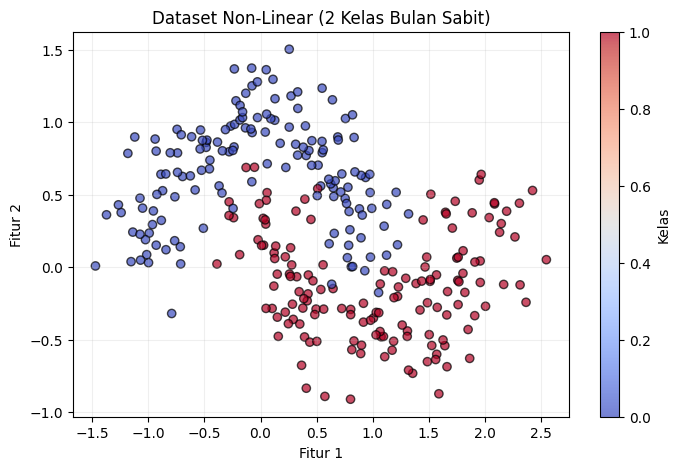

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset non-linear
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

# Visualisasi dataset
plt.figure(figsize=(8, 5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.7,
    edgecolors="k"
)

plt.title("Dataset Non-Linear (2 Kelas Bulan Sabit)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.colorbar(label="Kelas")
plt.grid(alpha=0.2)
plt.show()

**Langkah 2 — Bangun dan Latih Neural Network**

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import set_random_seed

# Menetapkan random seed agar hasil lebih konsisten
set_random_seed(42)

# Membagi dataset menjadi data training dan data testing
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_tr))
print("Jumlah data testing :", len(X_te))

# Membangun neural network
model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Konfigurasi proses training
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Menampilkan arsitektur model
model.summary()

# Melatih model
history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Jumlah data training: 240
Jumlah data testing : 60


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4531 - loss: 0.7180 - val_accuracy: 0.5000 - val_loss: 0.7024
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5833 - loss: 0.6827 - val_accuracy: 0.6875 - val_loss: 0.6686
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6771 - loss: 0.6543 - val_accuracy: 0.7292 - val_loss: 0.6407
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7708 - loss: 0.6298 - val_accuracy: 0.8125 - val_loss: 0.6153
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8073 - loss: 0.6066 - val_accuracy: 0.8125 - val_loss: 0.5911
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8385 - loss: 0.5836 - val_accuracy: 0.8333 - val_loss: 0.5669
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8646 - loss: 0.5598 - val_accuracy: 0.8333 - val_loss: 0.5422
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8698 - loss: 0.5347 - val_accuracy: 0.8333 - val_loss

**Langkah 3 — Evaluasi dan Visualisasi Kurva Belajar**

Loss pada data uji    : 0.401
Akurasi pada data uji: 0.800


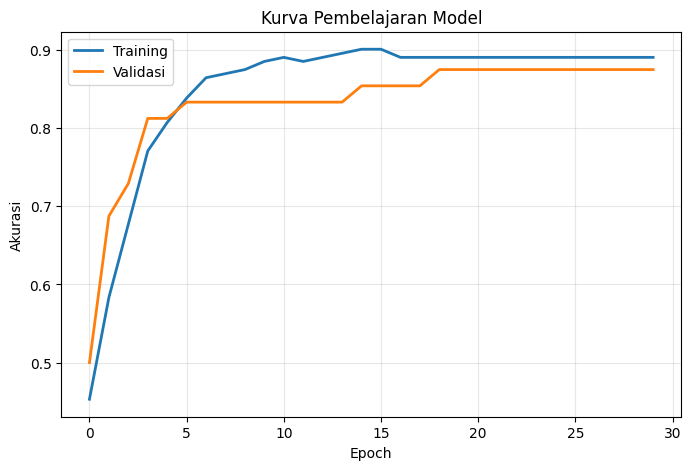

In [ ]:
# Mengevaluasi model pada data testing
loss, acc = model.evaluate(X_te, y_te, verbose=0)

print(f"Loss pada data uji    : {loss:.3f}")
print(f"Akurasi pada data uji: {acc:.3f}")

# Membuat grafik akurasi training dan validasi
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validasi",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.title("Kurva Pembelajaran Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Grafik Loss**

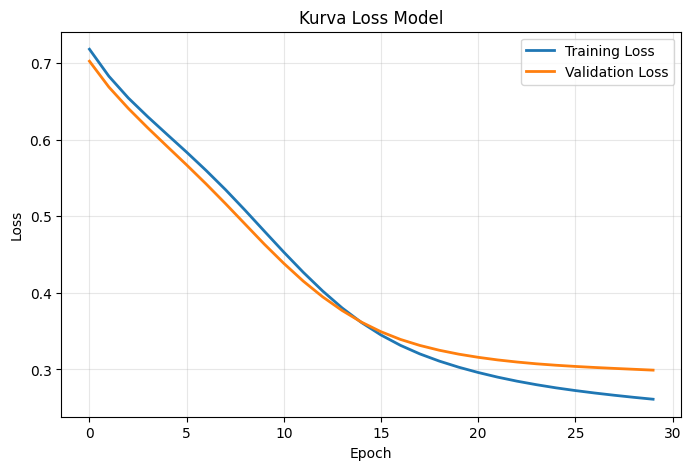

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Kurva Loss Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Visualisasi batas keputusan neural network**

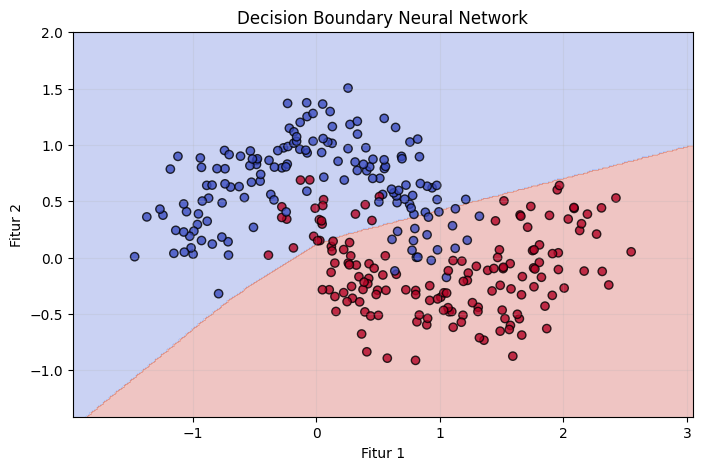

In [ ]:
# Menentukan batas area visualisasi
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# Membuat titik-titik grid
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Melakukan prediksi pada seluruh titik grid
probabilitas = model.predict(grid, verbose=0)
Z = (probabilitas >= 0.5).astype(int).reshape(xx.shape)

# Menampilkan decision boundary
plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.8
)

plt.title("Decision Boundary Neural Network")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.grid(alpha=0.2)
plt.show()

**Langkah 4 — Siapkan Dataset Ulasan Produk**

Dataset berikut berisi 40 ulasan: 20 positif dan 20 negatif.

In [ ]:
ulasan = [
    # Ulasan positif
    "Barangnya bagus banget, pengiriman cepat",
    "Sangat puas, akan beli lagi",
    "Recommended, harga sesuai kualitas",
    "Produknya sangat baik dan berfungsi sempurna",
    "Pelayanannya ramah dan responsif",
    "Barang sampai dengan aman dan cepat",
    "Kualitas produk sangat memuaskan",
    "Produk sesuai deskripsi dan terlihat bagus",
    "Kemasan rapi serta barang tidak rusak",
    "Harganya murah tetapi kualitasnya bagus",
    "Saya suka dengan produk ini",
    "Pengiriman tepat waktu dan penjual responsif",
    "Barang original dan kualitasnya sangat baik",
    "Produk bekerja dengan lancar tanpa masalah",
    "Desainnya bagus dan nyaman digunakan",
    "Pesanan diterima dalam kondisi sempurna",
    "Penjual memberikan pelayanan yang sangat baik",
    "Barang berkualitas dan layak dibeli",
    "Saya sangat senang dengan pembelian ini",
    "Produk memuaskan dan sesuai ekspektasi",

    # Ulasan negatif
    "Kualitas jelek, tidak sesuai deskripsi",
    "Kecewa, barang rusak saat sampai",
    "Buruk sekali, tidak sesuai ekspektasi",
    "Pengiriman sangat lambat dan mengecewakan",
    "Produknya tidak dapat digunakan",
    "Barang yang datang berbeda dari foto",
    "Kemasannya rusak dan barangnya lecet",
    "Kualitas sangat buruk untuk harga tersebut",
    "Saya menyesal membeli produk ini",
    "Pelayanan penjual tidak ramah",
    "Barang cepat rusak setelah digunakan",
    "Produk palsu dan tidak sesuai keterangan",
    "Pesanan datang terlambat dan tidak lengkap",
    "Sangat mengecewakan, kualitasnya rendah",
    "Barang tidak berfungsi dengan baik",
    "Warna produk berbeda dari deskripsi",
    "Ukuran barang tidak sesuai pesanan",
    "Penjual tidak merespons keluhan pelanggan",
    "Produk gagal bekerja setelah satu hari",
    "Pengalaman belanja yang sangat buruk"
]

# 1 = positif dan 0 = negatif
label = [
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]

print("Jumlah ulasan:", len(ulasan))
print("Jumlah label :", len(label))
print("Ulasan positif:", label.count(1))
print("Ulasan negatif:", label.count(0))

Jumlah ulasan: 40
Jumlah label : 40
Ulasan positif: 20
Ulasan negatif: 20


**Langkah 5 — Mengubah Teks Menjadi TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat dan melatih TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

# Mengubah teks menjadi matriks TF-IDF
X_text = tfidf.fit_transform(ulasan)

# Mengambil nama seluruh fitur/kata
nama_fitur = tfidf.get_feature_names_out()

print("Ukuran matriks TF-IDF:", X_text.shape)
print("Jumlah kata/frasa unik:", len(nama_fitur))
print("\n10 fitur pertama:")
print(nama_fitur[:10])

Ukuran matriks TF-IDF: (40, 253)
Jumlah kata/frasa unik: 253

10 fitur pertama:
['akan' 'akan beli' 'aman' 'aman dan' 'bagus' 'bagus banget' 'bagus dan'
 'baik' 'baik dan' 'banget']


Melihat kata atau frasa dengan rata-rata skor TF-IDF tertinggi:

In [ ]:
# Menghitung rata-rata skor setiap fitur
rata_rata_tfidf = X_text.mean(axis=0).A1

# Mengurutkan indeks dari skor tertinggi
indeks_tertinggi = rata_rata_tfidf.argsort()[::-1][:15]

print("15 kata/frasa dengan rata-rata skor TF-IDF tertinggi:\n")

for indeks in indeks_tertinggi:
    print(
        f"{nama_fitur[indeks]:30s} "
        f"{rata_rata_tfidf[indeks]:.4f}"
    )

15 kata/frasa dengan rata-rata skor TF-IDF tertinggi:

dan                            0.0604
tidak                          0.0550
sangat                         0.0526
produk                         0.0493
barang                         0.0488
sesuai                         0.0443
dengan                         0.0321
kualitas                       0.0305
tidak sesuai                   0.0298
penjual                        0.0282
baik                           0.0279
rusak                          0.0276
bagus                          0.0274
digunakan                      0.0238
barang tidak                   0.0235


Visualisasi skor TF-IDF tertinggi:

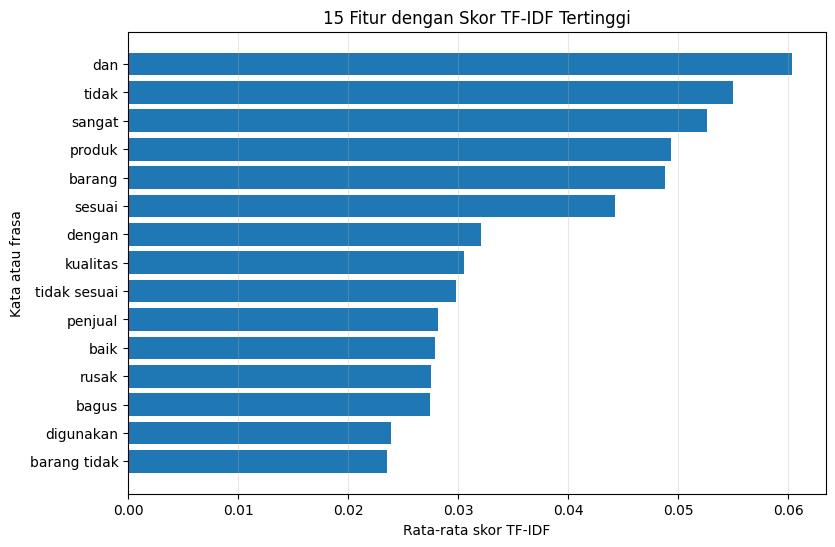

In [ ]:
fitur_tertinggi = nama_fitur[indeks_tertinggi]
skor_tertinggi = rata_rata_tfidf[indeks_tertinggi]

plt.figure(figsize=(9, 6))
plt.barh(fitur_tertinggi[::-1], skor_tertinggi[::-1])
plt.xlabel("Rata-rata skor TF-IDF")
plt.ylabel("Kata atau frasa")
plt.title("15 Fitur dengan Skor TF-IDF Tertinggi")
plt.grid(axis="x", alpha=0.3)
plt.show()

**Langkah 6 — Latih dan Evaluasi Model Sentimen**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Membagi teks asli menjadi data training dan testing
ulasan_tr, ulasan_te, label_tr, label_te = train_test_split(
    ulasan,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

# Membuat TF-IDF khusus untuk pemodelan
tfidf_model = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

# Fit hanya dilakukan pada data training
Xt_tr = tfidf_model.fit_transform(ulasan_tr)

# Data testing hanya ditransformasi
Xt_te = tfidf_model.transform(ulasan_te)

# Membuat dan melatih model Logistic Regression
model_sentimen = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_sentimen.fit(Xt_tr, label_tr)

# Melakukan prediksi pada data testing
prediksi_te = model_sentimen.predict(Xt_te)

# Menghitung akurasi
akurasi = accuracy_score(label_te, prediksi_te)

print(f"Akurasi model sentimen: {akurasi:.3f}")
print("\nLaporan klasifikasi:")
print(
    classification_report(
        label_te,
        prediksi_te,
        target_names=["Negatif", "Positif"],
        zero_division=0
    )
)

Akurasi model sentimen: 0.750

Laporan klasifikasi:
              precision    recall  f1-score   support

     Negatif       1.00      0.50      0.67         4
     Positif       0.67      1.00      0.80         4

    accuracy                           0.75         8
   macro avg       0.83      0.75      0.73         8
weighted avg       0.83      0.75      0.73         8



**Confusion matrix:**

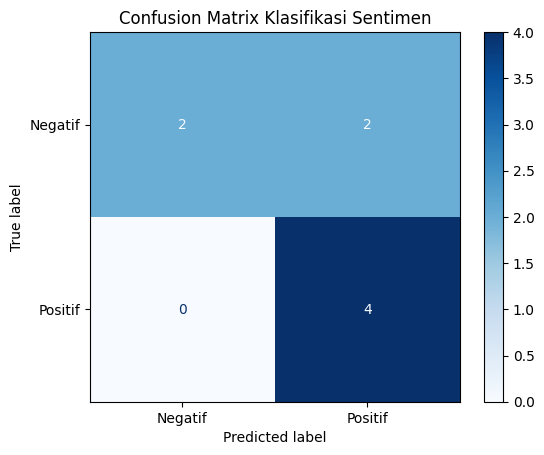

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    label_te,
    prediksi_te,
    display_labels=["Negatif", "Positif"],
    cmap="Blues"
)

plt.title("Confusion Matrix Klasifikasi Sentimen")
plt.show()

Tes kalimat baru

In [ ]:
kalimat_baru = [
    "Pelayanan sangat memuaskan dan ramah",
    "Barang rusak dan kualitasnya sangat buruk",
    "Pengiriman cepat dan produk sesuai deskripsi",
    "Saya kecewa karena barang tidak berfungsi"
]

# Mengubah kalimat baru menjadi TF-IDF
kalimat_tfidf = tfidf_model.transform(kalimat_baru)

# Prediksi kelas dan probabilitas
prediksi_baru = model_sentimen.predict(kalimat_tfidf)
probabilitas = model_sentimen.predict_proba(kalimat_tfidf)

for kalimat, hasil, probabilitas_kelas in zip(
    kalimat_baru,
    prediksi_baru,
    probabilitas
):
    sentimen = "Positif" if hasil == 1 else "Negatif"
    keyakinan = probabilitas_kelas[hasil]

    print(f"Kalimat    : {kalimat}")
    print(f"Prediksi   : {sentimen}")
    print(f"Probabilitas: {keyakinan:.2%}")
    print("-" * 60)

Kalimat    : Pelayanan sangat memuaskan dan ramah
Prediksi   : Positif
Probabilitas: 59.19%
------------------------------------------------------------
Kalimat    : Barang rusak dan kualitasnya sangat buruk
Prediksi   : Positif
Probabilitas: 50.43%
------------------------------------------------------------
Kalimat    : Pengiriman cepat dan produk sesuai deskripsi
Prediksi   : Positif
Probabilitas: 52.22%
------------------------------------------------------------
Kalimat    : Saya kecewa karena barang tidak berfungsi
Prediksi   : Negatif
Probabilitas: 53.52%
------------------------------------------------------------


**Kesimpulan**

1. Dataset `make_moons` mempunyai pola non-linear sehingga tidak dapat
   dipisahkan dengan satu garis lurus.
2. Neural network dengan dua hidden layer dan activation function ReLU mampu
   mempelajari pola melengkung pada dataset.
3. Activation function sigmoid pada output menghasilkan probabilitas untuk
   klasifikasi biner.
4. TF-IDF mengubah ulasan berbentuk teks menjadi representasi numerik
   berdasarkan tingkat kepentingan kata atau frasa.
5. Logistic Regression kemudian menggunakan fitur TF-IDF untuk memprediksi
   apakah suatu ulasan memiliki sentimen positif atau negatif.
6. Karena dataset ulasan hanya terdiri dari 40 data, nilai akurasi dapat
   berubah secara signifikan dan belum menggambarkan performa model pada data
   dunia nyata. Dataset yang lebih besar dan beragam diperlukan untuk
   menghasilkan model yang lebih andal.